In [1]:
!pip install jamo
!pip install jamotools

In [3]:
# Core
import torch
import torchaudio
import os
import json
import pandas as pd
from tqdm.auto import tqdm

# Wav2Vec2
from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor

# Jamo handling
from jamo import h2j, j2hcj
import jamotools


# Visualization
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [4]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# Verify GPU
print(f"✅ GPU Active: {torch.cuda.is_available()}")
print(f"🖥️ Device: {torch.cuda.get_device_name(0)}")

# Load the saved ASR model and processor
MODEL_PATH = "/content/drive/MyDrive/manual_datasets/clovacall_data/final_asr_jamo_model"

processor = Wav2Vec2Processor.from_pretrained(MODEL_PATH)
model = Wav2Vec2ForCTC.from_pretrained(MODEL_PATH).to("cuda")
model.eval()

print(f"✅ Model and Processor loaded from: {MODEL_PATH}")
print(f"📦 Vocab size: {len(processor.tokenizer)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ GPU Active: True
🖥️ Device: Tesla T4


Loading weights:   0%|          | 0/213 [00:00<?, ?it/s]

✅ Model and Processor loaded from: /content/drive/MyDrive/manual_datasets/clovacall_data/final_asr_jamo_model
📦 Vocab size: 82


In [5]:
# Paths
AUDIO_DIR = "/content/drive/MyDrive/manual_datasets/clovacall_data/wavs_resampled_16k/"
TRAIN_JSON = "/content/drive/MyDrive/manual_datasets/clovacall_data/train_ClovaCall.json"

# Load only train metadata
train_df = pd.read_json(TRAIN_JSON)

# Split into train / val / test entirely from train_ClovaCall
train_split, temp_df = train_test_split(train_df, test_size=0.2, random_state=42)
val_split, test_split = train_test_split(temp_df, test_size=0.5, random_state=42)

# Use a small subset of the test split for scoring
val_subset = val_split.sample(n=100, random_state=42)

print(f"✅ Train size: {len(train_split)}")
print(f"✅ Val size:   {len(val_split)}")
print(f"✅ Test size:  {len(test_split)}")
print(f"✅ Scoring subset: {len(val_subset)} samples")
print(val_subset[['wav', 'text']].head())

✅ Train size: 47729
✅ Val size:   5966
✅ Test size:  5967
✅ Scoring subset: 100 samples
                              wav                   text
17020  42_0524_497_0_00412_09.wav        쿠폰으로 중복할인이 되나요?
7327   41_0610_377_0_10102_00.wav            추석에도 영업하나요?
7175   41_0523_583_0_07419_07.wav           몇 시 까지 영업해요?
54588  44_0603_431_0_05264_07.wav  차를 가져가는데 혹시 발레파킹 될까요?
19980  44_0521_133_0_04712_09.wav           런치 타임이 몇시에요?


In [6]:
def compute_edit_distance(ref, hyp):
    N, M = len(ref), len(hyp)
    dp = [[0] * (M + 1) for _ in range(N + 1)]
    for i in range(N + 1): dp[i][0] = i
    for j in range(M + 1): dp[0][j] = j
    for i in range(1, N + 1):
        for j in range(1, M + 1):
            if ref[i-1] == hyp[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = 1 + min(dp[i-1][j-1], dp[i-1][j], dp[i][j-1])
    return dp

def backtrack(dp, ref, hyp):
    i, j = len(ref), len(hyp)
    operations = []
    while i > 0 or j > 0:
        if i > 0 and j > 0 and ref[i-1] == hyp[j-1]:
            i -= 1; j -= 1
        elif i > 0 and j > 0 and dp[i][j] == dp[i-1][j-1] + 1:
            operations.append({
                "position": i, "type": "substitution",
                "expected": ref[i-1], "predicted": hyp[j-1],
                "expected_jamo": jamotools.split_syllables(ref[i-1]),
                "predicted_jamo": jamotools.split_syllables(hyp[j-1])
            })
            i -= 1; j -= 1
        elif i > 0 and dp[i][j] == dp[i-1][j] + 1:
            operations.append({
                "position": i, "type": "deletion",
                "expected": ref[i-1], "predicted": "[missing]",
                "expected_jamo": jamotools.split_syllables(ref[i-1]),
                "predicted_jamo": ""
            })
            i -= 1
        else:
            operations.append({
                "position": j, "type": "insertion",
                "expected": "[none]", "predicted": hyp[j-1],
                "expected_jamo": "",
                "predicted_jamo": jamotools.split_syllables(hyp[j-1])
            })
            j -= 1
    operations.reverse()
    return operations

def score_pronunciation(reference_hangul, predicted_hangul):
    reference_hangul = reference_hangul.replace(" ", "")
    predicted_hangul = predicted_hangul.replace(" ", "")
    ref_jamo = list(jamotools.split_syllables(reference_hangul))
    hyp_jamo = list(jamotools.split_syllables(predicted_hangul))
    dp = compute_edit_distance(ref_jamo, hyp_jamo)
    total_edits = dp[len(ref_jamo)][len(hyp_jamo)]
    per = total_edits / len(ref_jamo) if len(ref_jamo) > 0 else 0.0
    ops = backtrack(dp, ref_jamo, hyp_jamo)
    return {
        "per": per,
        "substitutions": sum(1 for o in ops if o["type"] == "substitution"),
        "deletions": sum(1 for o in ops if o["type"] == "deletion"),
        "insertions": sum(1 for o in ops if o["type"] == "insertion"),
    }

def get_syllable_errors(reference_hangul, predicted_hangul):
    reference_hangul = reference_hangul.replace(" ", "")
    predicted_hangul = predicted_hangul.replace(" ", "")
    ref_syllables = list(reference_hangul)
    hyp_syllables = list(predicted_hangul)
    dp = compute_edit_distance(ref_syllables, hyp_syllables)
    return backtrack(dp, ref_syllables, hyp_syllables)

print("✅ Custom edit distance scorer defined — no jiwer or difflib used")

✅ Custom edit distance scorer defined — no jiwer or difflib used


In [7]:
def is_silent(speech, threshold=0.01):
    return speech.abs().max().item() < threshold

def evaluate_pronunciation(model, processor, val_subset, audio_dir, num_samples=10):
    results = []

    for i, row in tqdm(val_subset.head(num_samples).iterrows(), total=num_samples, desc="Scoring"):
        wav_path = os.path.join(audio_dir, row['wav'])
        try:
            speech, sr = torchaudio.load(wav_path)
        except Exception:
            continue  # skip unreadable files entirely

        # Skip silent files
        if is_silent(speech):
            print(f"⚠️ Skipping silent file: {row['wav']}")
            continue

        input_values = processor(
            speech.squeeze().numpy(),
            sampling_rate=16000,
            return_tensors="pt"
        ).input_values.to("cuda")

        with torch.no_grad():
            logits = model(input_values).logits

        pred_ids = torch.argmax(logits, dim=-1)
        pred_jamo = processor.batch_decode(pred_ids)[0]
        predicted_hangul = jamotools.join_jamos(pred_jamo)

        # Skip if prediction is empty after joining
        if not predicted_hangul.strip():
            print(f"⚠️ Empty prediction for: {row['wav']}")
            continue

        reference_hangul = row['text']
        scores = score_pronunciation(reference_hangul, predicted_hangul)
        errors = get_syllable_errors(reference_hangul, predicted_hangul)

        results.append({
            "sample": i + 1,
            "reference": reference_hangul,
            "prediction": predicted_hangul,
            "PER": f"{scores['per']*100:.1f}%",
            "substitutions": scores["substitutions"],
            "deletions": scores["deletions"],
            "insertions": scores["insertions"],
            "error_locations": errors
        })

    return results

results = evaluate_pronunciation(model, processor, val_subset, AUDIO_DIR, num_samples=10)

for r in results[:5]:
    print(f"\nSample {r['sample']}")
    print(f"  Reference:  {r['reference']}")
    print(f"  Predicted:  {r['prediction']}")
    print(f"  PER:        {r['PER']}")
    print(f"  Errors:     {r['error_locations']}")

Scoring:   0%|          | 0/10 [00:00<?, ?it/s]


Sample 7328
  Reference:  추석에도 영업하나요?
  Predicted:  추석에도 영업하나요?
  PER:        0.0%
  Errors:     []

Sample 7176
  Reference:  몇 시 까지 영업해요?
  Predicted:  몇시까지 영업해요?
  PER:        0.0%
  Errors:     []

Sample 54589
  Reference:  차를 가져가는데 혹시 발레파킹 될까요?
  Predicted:  차를 가져 가는데 혹시 발레 파킹이될까요?
  PER:        5.1%
  Errors:     [{'position': 14, 'type': 'insertion', 'expected': '[none]', 'predicted': '이', 'expected_jamo': '', 'predicted_jamo': 'ㅇㅣ'}]

Sample 19981
  Reference:  런치 타임이 몇시에요?
  Predicted:  런치 타임이 몇시에요?
  PER:        0.0%
  Errors:     []

Sample 40803
  Reference:  주문은 언제까지 받으시나요?
  Predicted:  주문은 언제까지 받으시나요?
  PER:        0.0%
  Errors:     []


In [8]:
RESULTS_DIR = "/content/drive/MyDrive/manual_datasets/clovacall_data/scorer_results/"
os.makedirs(RESULTS_DIR, exist_ok=True)

# Save as CSV (without error_locations since it's nested)
df_results = pd.DataFrame([{
    "sample": r["sample"],
    "reference": r["reference"],
    "prediction": r["prediction"],
    "PER": r["PER"],
    "substitutions": r["substitutions"],
    "deletions": r["deletions"],
    "insertions": r["insertions"],
} for r in results])

csv_path = os.path.join(RESULTS_DIR, "scorer_results.csv")
df_results.to_csv(csv_path, index=False, encoding="utf-8-sig")

# Save full results including error locations as JSON
json_path = os.path.join(RESULTS_DIR, "scorer_results.json")
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print(f"✅ CSV saved to: {csv_path}")
print(f"✅ JSON saved to: {json_path}")
print(df_results)

✅ CSV saved to: /content/drive/MyDrive/manual_datasets/clovacall_data/scorer_results/scorer_results.csv
✅ JSON saved to: /content/drive/MyDrive/manual_datasets/clovacall_data/scorer_results/scorer_results.json
   sample                reference               prediction    PER  \
0    7328              추석에도 영업하나요?              추석에도 영업하나요?   0.0%   
1    7176             몇 시 까지 영업해요?               몇시까지 영업해요?   0.0%   
2   54589    차를 가져가는데 혹시 발레파킹 될까요?  차를 가져 가는데 혹시 발레 파킹이될까요?   5.1%   
3   19981             런치 타임이 몇시에요?             런치 타임이 몇시에요?   0.0%   
4   40803          주문은 언제까지 받으시나요?          주문은 언제까지 받으시나요?   0.0%   
5   37241     몇시부터 몇시까지 식사할 수 있나요?    몇시부터 몇시까지 식사 할 수 있나요?   0.0%   
6   36541  혹시 추천해주실 수 있는 메뉴가 있는지요?  혹시 추천해주실 수 있는 메뉴가 있는지요?   0.0%   
7    4147                  홍길동입니다.                 홍길동 입니다.   0.0%   
8   16681           잘 팔리는 메뉴는 뭔가요?            잘탈있는 메뉴는 뭔가요?  11.5%   

   substitutions  deletions  insertions  
0              0          0           0  
1    

In [10]:
def compute_global_per(all_refs, all_preds):
    total_edits = 0
    total_jamo = 0
    for ref, hyp in zip(all_refs, all_preds):
        ref_jamo = list(jamotools.split_syllables(ref))
        hyp_jamo = list(jamotools.split_syllables(hyp))
        dp = compute_edit_distance(ref_jamo, hyp_jamo)
        total_edits += dp[len(ref_jamo)][len(hyp_jamo)]
        total_jamo += len(ref_jamo)
    return total_edits / total_jamo if total_jamo > 0 else 0.0

def calculate_global_per(model, processor, val_subset, audio_dir):
    all_refs = []
    all_preds = []

    for i, row in tqdm(val_subset.iterrows(), total=len(val_subset), desc="Calculating Global PER"):
        wav_path = os.path.join(audio_dir, row['wav'])
        try:
            speech, sr = torchaudio.load(wav_path)
        except Exception:
            continue

        if is_silent(speech):
            continue

        input_values = processor(
            speech.squeeze().numpy(),
            sampling_rate=16000,
            return_tensors="pt"
        ).input_values.to("cuda")

        with torch.no_grad():
            logits = model(input_values).logits

        pred_ids = torch.argmax(logits, dim=-1)
        pred_jamo = processor.batch_decode(pred_ids)[0]
        predicted_hangul = jamotools.join_jamos(pred_jamo).replace(" ", "")
        reference_hangul = row['text'].replace(" ", "")

        all_refs.append(reference_hangul)
        all_preds.append(predicted_hangul)

    global_per = compute_global_per(all_refs, all_preds)

    print(f"\n✨ --- PRONUNCIATION SCORER SUMMARY --- ✨")
    print(f"📊 Samples evaluated: {len(all_refs)}")
    print(f"📊 Global Mean PER:   {global_per * 100:.2f}%")
    print(f"✅ Theoretical Accuracy: {(1 - global_per) * 100:.2f}%")

    return global_per

global_per = calculate_global_per(model, processor, val_subset, AUDIO_DIR)

Calculating Global PER:   0%|          | 0/100 [00:00<?, ?it/s]


✨ --- PRONUNCIATION SCORER SUMMARY --- ✨
📊 Samples evaluated: 100
📊 Global Mean PER:   4.23%
✅ Theoretical Accuracy: 95.77%


In [11]:
# Find which sample has 100% PER
for r in results:
    if float(r["PER"].replace("%", "")) > 50:
        print(f"Sample {r['sample']}")
        print(f"  Reference:  {r['reference']}")
        print(f"  Predicted:  {r['prediction']}")
        print(f"  PER:        {r['PER']}")
        print(f"  Errors:     {r['error_locations']}")

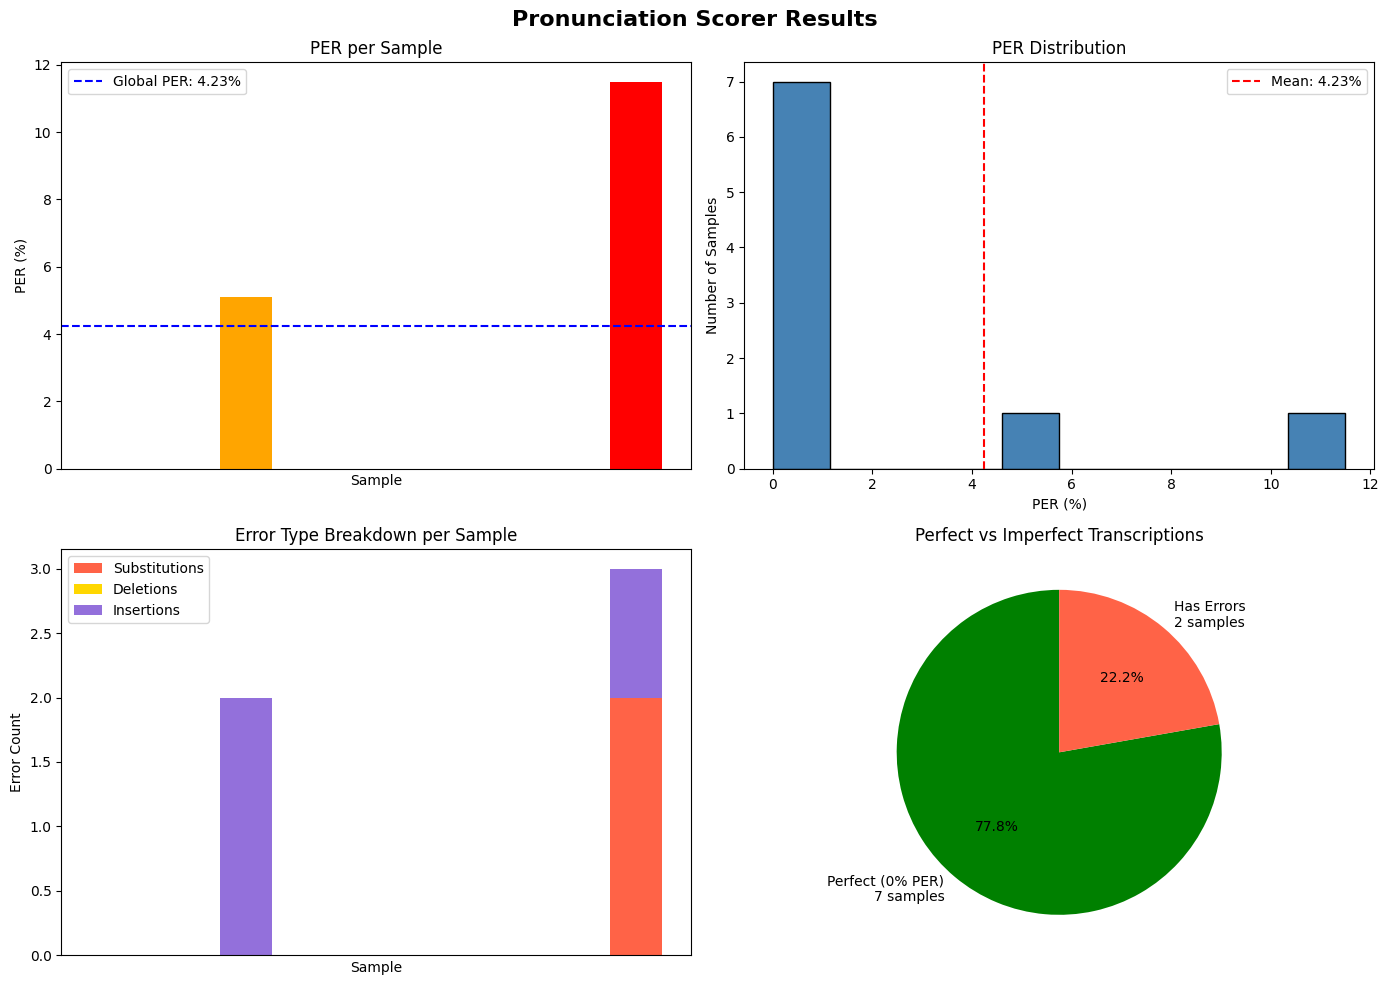

✅ Plots saved to: /content/drive/MyDrive/manual_datasets/clovacall_data/scorer_results/scorer_plots.png


In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Extract PER values as floats
per_values = [float(r["PER"].replace("%", "")) for r in results]
samples = [str(r["sample"]) for r in results]
substitutions = [r["substitutions"] for r in results]
deletions = [r["deletions"] for r in results]
insertions = [r["insertions"] for r in results]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Pronunciation Scorer Results", fontsize=16, fontweight="bold")

# 1. PER per sample (bar chart)
ax1 = axes[0, 0]
colors = ["green" if p == 0 else "orange" if p < 10 else "red" for p in per_values]
ax1.bar(range(len(per_values)), per_values, color=colors)
ax1.axhline(y=global_per * 100, color="blue", linestyle="--", label=f"Global PER: {global_per*100:.2f}%")
ax1.set_title("PER per Sample")
ax1.set_xlabel("Sample")
ax1.set_ylabel("PER (%)")
ax1.legend()
ax1.set_xticks([])

# 2. PER distribution (histogram)
ax2 = axes[0, 1]
ax2.hist(per_values, bins=10, color="steelblue", edgecolor="black")
ax2.axvline(x=global_per * 100, color="red", linestyle="--", label=f"Mean: {global_per*100:.2f}%")
ax2.set_title("PER Distribution")
ax2.set_xlabel("PER (%)")
ax2.set_ylabel("Number of Samples")
ax2.legend()

# 3. Error type breakdown (stacked bar)
ax3 = axes[1, 0]
x = range(len(results))
ax3.bar(x, substitutions, label="Substitutions", color="tomato")
ax3.bar(x, deletions, bottom=substitutions, label="Deletions", color="gold")
ax3.bar(x, insertions, bottom=[s + d for s, d in zip(substitutions, deletions)], label="Insertions", color="mediumpurple")
ax3.set_title("Error Type Breakdown per Sample")
ax3.set_xlabel("Sample")
ax3.set_ylabel("Error Count")
ax3.legend()
ax3.set_xticks([])

# 4. Overall accuracy pie chart
ax4 = axes[1, 1]
correct = sum(1 for p in per_values if p == 0.0)
incorrect = len(per_values) - correct
ax4.pie(
    [correct, incorrect],
    labels=[f"Perfect (0% PER)\n{correct} samples", f"Has Errors\n{incorrect} samples"],
    colors=["green", "tomato"],
    autopct="%1.1f%%",
    startangle=90
)
ax4.set_title("Perfect vs Imperfect Transcriptions")

plt.tight_layout()

# Save to Drive
plot_path = os.path.join(RESULTS_DIR, "scorer_plots.png")
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"✅ Plots saved to: {plot_path}")